# Corporacion Favorita — Limpieza y Modelado TP

**Dataset:** Corporacion Favorita Grocery Sales Forecasting (Kaggle)

**Variables objetivo:**
- `demand7`: suma de ventas de los proximos 7 dias (regresion)
- `demand14`: suma de ventas de los proximos 14 dias (regresion)
- `perece`: si el producto es perecible — columna perishable de items.csv (clasificacion)

**Modelos:** Ridge vs LightGBM vs XGBoost

**Correcciones respecto a la version anterior:**
- Merge corregido: se eliminan columnas duplicadas (_x, _y)
- Se carga el dataset completo (sin nrows) para tener 4 anos de datos
- Se agregan lag features para reducir el WAPE
- Se agrega modelo de clasificacion para perece

---

**Librerias**

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn lightgbm xgboost -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, zipfile

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import lightgbm as lgb
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

**Cargar archivos**

In [3]:
!p7zip -d '/content/train.csv.7z'
!p7zip -d '/content/stores.csv.7z'
!p7zip -d '/content/items.csv.7z'
!p7zip -d '/content/transactions.csv.7z'
!p7zip -d '/content/oil.csv.7z'
!p7zip -d '/content/holidays_events.csv.7z'
#!p7zip -d '/content/test.csv.7z'


7-Zip (a) [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 474092593 bytes (453 MiB)

Extracting archive: /content/train.csv.7z
--
Path = /content/train.csv.7z
Type = 7z
Physical Size = 474092593
Headers Size = 122
Method = LZMA2:24
Solid = -
Blocks = 1

  0%      0% - train.csv                  1% - train.csv                  2% - train.csv                  3% - train.csv                  4% - train.csv                  5% - train.csv                  6% - train.csv                  7% - train.csv

In [4]:
BASE       = ''
TRAIN_PATH = 'train.csv'

items        = pd.read_csv(f'{BASE}items.csv')
stores       = pd.read_csv(f'{BASE}stores.csv')
oil          = pd.read_csv(f'{BASE}oil.csv',             parse_dates=['date'])
holidays     = pd.read_csv(f'{BASE}holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(f'{BASE}transactions.csv',    parse_dates=['date'])

print('items:       ', items.shape)
print('stores:      ', stores.shape)
print('oil:         ', oil.shape)
print('holidays:    ', holidays.shape)
print('transactions:', transactions.shape)

items:        (4100, 4)
stores:       (54, 5)
oil:          (1218, 2)
holidays:     (350, 6)
transactions: (83488, 3)


In [5]:
print('Cargando muestra de train.csv (3 millones de filas)...')
train = pd.read_csv(
    'train.csv',
    parse_dates=['date'],
    dtype={
        'id':         'int32',
        'store_nbr':  'int8',
        'item_nbr':   'int32',
        'unit_sales': 'float32',
        'onpromotion':'object'
    },
    nrows=5_000_000
)

train.head(3)

Cargando muestra de train.csv (3 millones de filas)...


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN


---

**Merge de tablas**


In [6]:
# Festivos nacionales: un registro por fecha, prioridad por tipo
PRIORIDAD = {'Holiday':0,'Event':1,'Additional':2,'Bridge':3,'Transfer':4,'Work Day':5}
hol_nac = (
    holidays[holidays['locale']=='National']
    .assign(prio=lambda x: x['type'].map(PRIORIDAD))
    .sort_values('prio')
    .drop_duplicates('date', keep='first')
    [['date','type','transferred']]
    .rename(columns={'type':'holiday_type'})
)

# Merge: train + items (solo columnas necesarias para evitar duplicados)
df = train.merge(
    items[['item_nbr','family','class','perishable']],
    on='item_nbr', how='left'
)
# + stores
df = df.merge(
    stores[['store_nbr','city','state','type','cluster']],
    on='store_nbr', how='left'
)
# + oil
df = df.merge(oil, on='date', how='left')
# + festivos
df = df.merge(hol_nac, on='date', how='left')
# + transactions
df = df.merge(
    transactions.rename(columns={'transactions':'n_transactions'}),
    on=['date','store_nbr'], how='left'
)

# Eliminar columna id (no aporta al modelo)
df.drop(columns=['id'], inplace=True)

print('Shape despues del merge:', df.shape)
print('Columnas:', df.columns.tolist())

Shape despues del merge: (5000000, 16)
Columnas: ['date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion', 'family', 'class', 'perishable', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'holiday_type', 'transferred', 'n_transactions']


In [7]:
# Filtrar solo familias de alimentos
FAMILIAS = [
    'PRODUCE','MEATS','SEAFOOD','DAIRY','BREAD/BAKERY',
    'EGGS','POULTRY','BEVERAGES','GROCERY I','GROCERY II',
    'DELI','PREPARED FOODS'
]

df = df[df['family'].isin(FAMILIAS)].copy()
df = df.sort_values(['store_nbr','item_nbr','date']).reset_index(drop=True)

print('Shape despues del filtro:', df.shape)
print('Familias:', df['family'].nunique())
print('Rango fechas:', df['date'].min().date(), 'a', df['date'].max().date())

Shape despues del filtro: (3738421, 16)
Familias: 12
Rango fechas: 2013-01-01 a 2013-05-01


---

**Valores nulos**

In [8]:
nulos = pd.DataFrame(df.isnull().sum(), columns=['Nulos'])
nulos['Porcentaje'] = (nulos['Nulos'] / len(df) * 100).round(2)
nulos[nulos['Nulos'] > 0]

,Nulos,Porcentaje
onpromotion,3738421,100.00
dcoilwtico,1207014,32.29
holiday_type,3569006,95.47
transferred,3569006,95.47


In [9]:
# unit_sales negativos = devoluciones, se convierten a 0
df['unit_sales'] = df['unit_sales'].clip(lower=0)

# dcoilwtico: nulos en dias sin cotizacion bursatil
# Forward fill: precio del dia anterior
df['dcoilwtico'] = df['dcoilwtico'].fillna(method='ffill').fillna(method='bfill')

# holiday_type y transferred: nulo = dia ordinario
df['holiday_type'] = df['holiday_type'].fillna('Normal')
df['transferred']  = df['transferred'].fillna(False)

# onpromotion: nulo significa que no hay promocion
df['onpromotion'] = df['onpromotion'].fillna(False).astype(int)

# n_transactions: mediana por tienda y dia de semana
if df['n_transactions'].isnull().sum() > 0:
    df['dow_tmp'] = df['date'].dt.dayofweek
    med = df.groupby(['store_nbr','dow_tmp'])['n_transactions'].transform('median')
    df['n_transactions'] = df['n_transactions'].fillna(med).fillna(df['n_transactions'].median())
    df.drop(columns=['dow_tmp'], inplace=True)

print('Nulos despues de imputacion:', df.isnull().sum().sum())

Nulos despues de imputacion: 0


---

**Tratamiento de outliers**

unit_sales antes:
  Min: 0.0
  Max: 9431.0
  Media: 9.266


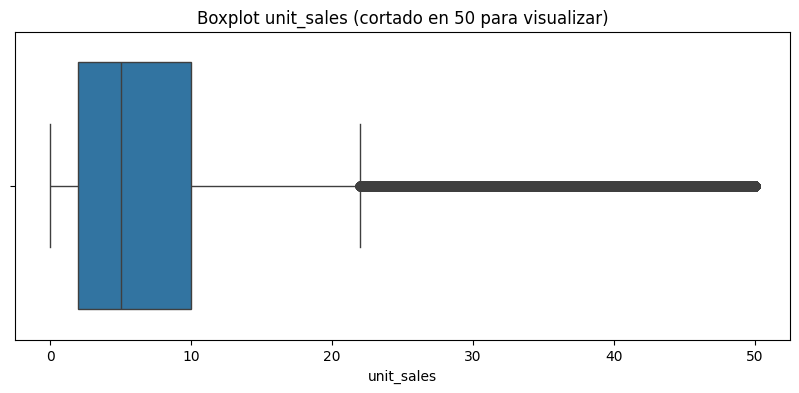

In [10]:
print('unit_sales antes:')
print('  Min:', df['unit_sales'].min())
print('  Max:', df['unit_sales'].max())
print('  Media:', df['unit_sales'].mean().round(3))

plt.figure(figsize=(10,4))
sns.boxplot(x=df['unit_sales'].clip(upper=50))
plt.title('Boxplot unit_sales (cortado en 50 para visualizar)')
plt.show()

In [11]:
# IQR con factor 3.0
# Factor conservador para preservar picos reales de festivos y promociones
Q1  = df['unit_sales'].quantile(0.25)
Q3  = df['unit_sales'].quantile(0.75)
IQR = Q3 - Q1

up_limit   = Q3 + 3.0 * IQR
down_limit = max(0.0, Q1 - 3.0 * IQR)

print('Limite superior:', up_limit)
print('Limite inferior:', down_limit)
print('Outliers:', ((df['unit_sales'] > up_limit) | (df['unit_sales'] < down_limit)).sum())

Limite superior: 34.0
Limite inferior: 0.0
Outliers: 160728


In [12]:
df['unit_sales'] = np.where(
    df['unit_sales'] > up_limit,
    up_limit,
    np.where(
        df['unit_sales'] < down_limit,
        down_limit,
        df['unit_sales']
    )
)

unit_sales despues:
  Min: 0.0
  Max: 34.0
  Media: 7.885


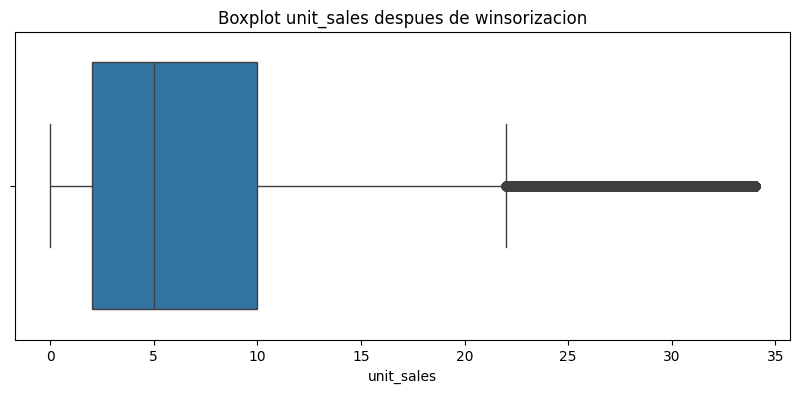

In [13]:
print('unit_sales despues:')
print('  Min:', df['unit_sales'].min())
print('  Max:', df['unit_sales'].max())
print('  Media:', df['unit_sales'].mean().round(3))

plt.figure(figsize=(10,4))
sns.boxplot(x=df['unit_sales'])
plt.title('Boxplot unit_sales despues de winsorizacion')
plt.show()

In [14]:
# n_transactions
Q1_t = df['n_transactions'].quantile(0.25)
Q3_t = df['n_transactions'].quantile(0.75)
lim_t = Q3_t + 3.0 * (Q3_t - Q1_t)
df['n_transactions'] = df['n_transactions'].clip(upper=lim_t)
print('n_transactions winsorizado en:', lim_t.round(1))

n_transactions winsorizado en: 6267.0


---

**Normalizacion y estandarizacion**

Asimetria unit_sales:      1.78
Asimetria log_unit_sales:  0.42


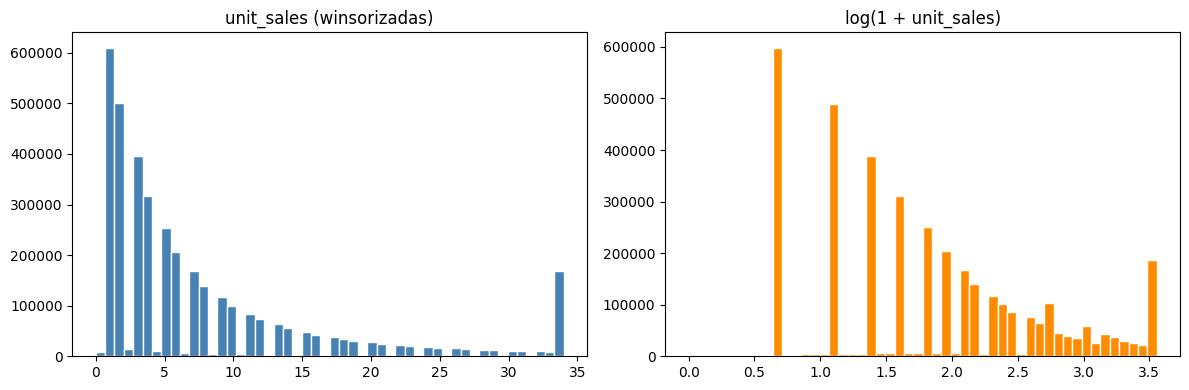

In [15]:
# Transformacion logaritmica de unit_sales
df['log_unit_sales'] = np.log1p(df['unit_sales'])

print('Asimetria unit_sales:     ', df['unit_sales'].skew().round(2))
print('Asimetria log_unit_sales: ', df['log_unit_sales'].skew().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['unit_sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('unit_sales (winsorizadas)')
axes[1].hist(df['log_unit_sales'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('log(1 + unit_sales)')
plt.tight_layout()
plt.show()

In [16]:
mm = MinMaxScaler()
df[['dcoilwtico_scaled','n_transactions_scaled']] = mm.fit_transform(
    df[['dcoilwtico','n_transactions']]
)

# StandardScaler para log_unit_sales
std_sc = StandardScaler()
df['log_unit_sales_std'] = std_sc.fit_transform(df[['log_unit_sales']])

print('dcoilwtico_scaled:      min=', round(df['dcoilwtico_scaled'].min(), 3),
      '  max=', round(df['dcoilwtico_scaled'].max(), 3))
print('n_transactions_scaled:  min=', round(df['n_transactions_scaled'].min(), 3),
      '  max=', round(df['n_transactions_scaled'].max(), 3))
print('log_unit_sales_std:     media=', round(df['log_unit_sales_std'].mean(), 4),
      '  std=', round(df['log_unit_sales_std'].std(), 4))

dcoilwtico_scaled:      min= 0.0   max= 1.0
n_transactions_scaled:  min= 0.0   max= 1.0
log_unit_sales_std:     media= -0.0   std= 1.0


---

**Features de contexto y lag features**


In [17]:
# Variables temporales
df['dia_semana']  = df['date'].dt.dayofweek
df['es_finde']    = (df['dia_semana'] >= 5).astype(int)
df['mes']         = df['date'].dt.month
df['semana_anio'] = df['date'].dt.isocalendar().week.astype(int)
df['anio']        = df['date'].dt.year
df['trimestre']   = df['date'].dt.quarter
df['es_festivo']  = (df['holiday_type'] != 'Normal').astype(int)

# Encoding de categoricas
df['store_type_enc'] = df['type'].map({'A':1,'B':2,'C':3,'D':4,'E':5})
df['family_enc']     = df['family'].astype('category').cat.codes
df['city_enc']       = df['city'].astype('category').cat.codes
df['state_enc']      = df['state'].astype('category').cat.codes

print('Variables temporales y encoding creados')

Variables temporales y encoding creados


In [18]:
# Lag features por serie (store_nbr + item_nbr)
# Estas variables son las mas importantes para reducir el WAPE
# Le dicen al modelo cuanto se vendio ayer, hace 7 dias y hace 14 dias

print('Creando lag features... (puede tardar unos minutos)')

def crear_lags(group):
    s = group['unit_sales']
    group['lag_1']        = s.shift(1)                              # venta de ayer
    group['lag_7']        = s.shift(7)                              # venta hace 7 dias
    group['lag_14']       = s.shift(14)                             # venta hace 14 dias
    group['media_7d']     = s.shift(1).rolling(7,  min_periods=3).mean()  # promedio 7d
    group['media_14d']    = s.shift(1).rolling(14, min_periods=5).mean()  # promedio 14d
    group['std_7d']       = s.shift(1).rolling(7,  min_periods=3).std().fillna(0)
    return group

df = df.groupby(['store_nbr','item_nbr'], group_keys=False).apply(crear_lags)

print('Lag features creados: lag_1, lag_7, lag_14, media_7d, media_14d, std_7d')

Creando lag features... (puede tardar unos minutos)
Lag features creados: lag_1, lag_7, lag_14, media_7d, media_14d, std_7d


---

**Construccion de variables objetivo**

- `perece`: ya existe como perishable en items.csv
- `demand7` y `demand14`: suma de ventas de los proximos 7 y 14 dias

In [19]:
# perece: columna perishable ya viene del merge con items.csv
# Solo se renombra para coincidir con el nombre del proyecto
df['perece'] = df['perishable']

print('perece:')
print(df['perece'].value_counts())

perece:
perece
0    2652288
1    1086133
Name: count, dtype: int64


In [20]:
# demand7 y demand14
print('Construyendo demand7 y demand14...')

def construir_demand(group):
    s = group['unit_sales']
    group['demand7']  = s.shift(-1).rolling(7,  min_periods=4).sum().shift(-6)
    group['demand14'] = s.shift(-1).rolling(14, min_periods=8).sum().shift(-13)
    return group

df = df.groupby(['store_nbr','item_nbr'], group_keys=False).apply(construir_demand)

print('demand7  con valor:', df['demand7'].notna().sum())
print('demand14 con valor:', df['demand14'].notna().sum())

Construyendo demand7 y demand14...
demand7  con valor: 3489697
demand14 con valor: 3204329


In [21]:
# Eliminar filas sin target y sin lag features
LAG_COLS = ['lag_1','lag_7','lag_14','media_7d','media_14d']
df = df.dropna(subset=['demand7','demand14'] + LAG_COLS).reset_index(drop=True)

ratio = df['demand14'].mean() / df['demand7'].mean()
print('Shape final:', df.shape)
print('Ratio demand14/demand7:', ratio.round(3), '(esperado ~2.0)')

Shape final: (2646249, 40)
Ratio demand14/demand7: 2.001 (esperado ~2.0)


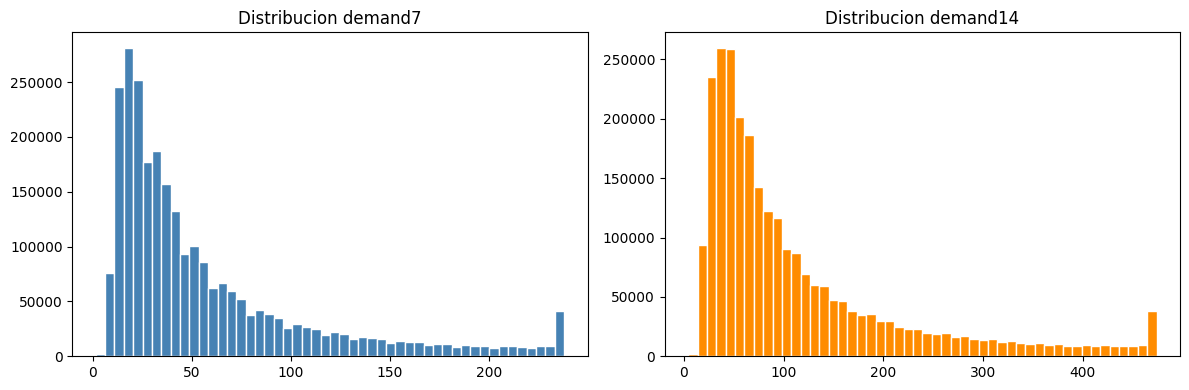

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['demand7'].clip(upper=df['demand7'].quantile(0.99)),
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion demand7')
axes[1].hist(df['demand14'].clip(upper=df['demand14'].quantile(0.99)),
             bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribucion demand14')
plt.tight_layout()
plt.show()

---

**Exportar dataset limpio**

In [23]:
COLUMNAS = [
    'date','store_nbr','item_nbr',
    'family','perishable','city','state','type','cluster',
    'unit_sales','log_unit_sales','log_unit_sales_std',
    'onpromotion',
    'dcoilwtico','dcoilwtico_scaled',
    'n_transactions','n_transactions_scaled',
    'es_festivo','dia_semana','es_finde','mes','semana_anio','anio','trimestre',
    'store_type_enc','family_enc','city_enc','state_enc',
    'lag_1','lag_7','lag_14','media_7d','media_14d','std_7d',
    'demand7','demand14','perece'
]

df_clean = df[COLUMNAS].copy()
df_clean.to_csv('favorita_aldimi_limpio.csv', index=False)

print('Exportado: favorita_aldimi_limpio.csv')
print('Shape:', df_clean.shape)
print('Nulos:', df_clean.isnull().sum().sum())

Exportado: favorita_aldimi_limpio.csv
Shape: (2646249, 37)
Nulos: 0


In [24]:
try:
    from google.colab import files
    files.download('favorita_aldimi_limpio.csv')
except:
    print('Guardado en:', os.path.abspath('favorita_aldimi_limpio.csv'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

**Preparacion para el modelado**

In [25]:
# Features: ahora incluyen los lag features que reduciran el WAPE
FEATURES = [
    # Lag features (los mas importantes)
    'lag_1','lag_7','lag_14','media_7d','media_14d','std_7d',
    # Contexto comercial
    'log_unit_sales','onpromotion',
    'dcoilwtico_scaled','n_transactions_scaled',
    'es_festivo','dia_semana','es_finde',
    'mes','semana_anio','anio','trimestre',
    # Categoricas codificadas
    'store_type_enc','family_enc','city_enc','cluster'
]

X   = df_clean[FEATURES]
y7  = df_clean['demand7']
y14 = df_clean['demand14']
yp  = df_clean['perece']

print('X shape:', X.shape)
print('Features:', len(FEATURES))

X shape: (2646249, 21)
Features: 21


In [26]:
# Split temporal 80/20
# No se usa split aleatorio porque son series temporales (causaria data leakage)
fechas = sorted(df_clean['date'].unique())
corte  = fechas[int(len(fechas) * 0.80)]

mask_tr = df_clean['date'] <  corte
mask_te = df_clean['date'] >= corte

X_train,  X_test  = X[mask_tr],   X[mask_te]
y7_train, y7_test = y7[mask_tr],  y7[mask_te]
y14_train,y14_test= y14[mask_tr], y14[mask_te]
yp_train, yp_test = yp[mask_tr],  yp[mask_te]

print('Train:', len(X_train), 'registros  |  ', mask_tr.sum()/len(df_clean)*100, '%')
print('Test: ', len(X_test),  'registros  |  ', mask_te.sum()/len(df_clean)*100, '%')
print('Corte:', corte)

Train: 2142778 registros  |   80.97416380695846 %
Test:  503471 registros  |   19.025836193041545 %
Corte: 2013-03-31 00:00:00


In [27]:
def wape(real, pred):
    return np.sum(np.abs(real - pred)) / (np.sum(np.abs(real)) + 1e-8)

def evaluar_reg(nombre, y_real, y_pred):
    print(f'--- {nombre} ---')
    print('  WAPE: ', round(wape(y_real, y_pred) * 100, 2), '%')
    print('  R2:   ', round(r2_score(y_real, y_pred), 4))
    print('  MAE:  ', round(mean_absolute_error(y_real, y_pred), 3))
    print('  RMSE: ', round(np.sqrt(mean_squared_error(y_real, y_pred)), 3))
    print()

---

**Entrenamiento - MODELO RIDGE (referencia)**

In [28]:
ridge7 = Ridge(alpha=1.0)
ridge7.fit(X_train, y7_train)
pred_ridge7 = np.maximum(ridge7.predict(X_test), 0)

ridge14 = Ridge(alpha=1.0)
ridge14.fit(X_train, y14_train)
pred_ridge14 = np.maximum(ridge14.predict(X_test), 0)

In [29]:
evaluar_reg('Ridge - demand7',  y7_test,  pred_ridge7)
evaluar_reg('Ridge - demand14', y14_test, pred_ridge14)

--- Ridge - demand7 ---
  WAPE:  16.98 %
  R2:    0.9224
  MAE:   10.362
  RMSE:  15.136

--- Ridge - demand14 ---
  WAPE:  14.98 %
  R2:    0.9377
  MAE:   18.031
  RMSE:  26.553



---

**Entrenamiento - MODELO LIGHTGBM**

In [30]:
lgbm7 = lgb.LGBMRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.04,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_samples=20,
    random_state=SEED,
    verbose=-1
)
lgbm7.fit(X_train, y7_train)
pred_lgbm7 = np.maximum(lgbm7.predict(X_test), 0)

In [31]:
lgbm14 = lgb.LGBMRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.04,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_samples=20,
    random_state=SEED,
    verbose=-1
)
lgbm14.fit(X_train, y14_train)
pred_lgbm14 = np.maximum(lgbm14.predict(X_test), 0)

In [32]:
evaluar_reg('LightGBM - demand7',  y7_test,  pred_lgbm7)
evaluar_reg('LightGBM - demand14', y14_test, pred_lgbm14)

--- LightGBM - demand7 ---
  WAPE:  18.13 %
  R2:    0.9123
  MAE:   11.064
  RMSE:  16.09

--- LightGBM - demand14 ---
  WAPE:  16.17 %
  R2:    0.927
  MAE:   19.462
  RMSE:  28.726



---

**Entrenamiento - MODELO XGBOOST**

In [33]:
xgb7 = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0
)
xgb7.fit(X_train, y7_train)
pred_xgb7 = np.maximum(xgb7.predict(X_test), 0)

In [34]:
xgb14 = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0
)
xgb14.fit(X_train, y14_train)
pred_xgb14 = np.maximum(xgb14.predict(X_test), 0)

In [35]:
evaluar_reg('XGBoost - demand7',  y7_test,  pred_xgb7)
evaluar_reg('XGBoost - demand14', y14_test, pred_xgb14)

--- XGBoost - demand7 ---
  WAPE:  18.19 %
  R2:    0.9117
  MAE:   11.098
  RMSE:  16.143

--- XGBoost - demand14 ---
  WAPE:  16.22 %
  R2:    0.9266
  MAE:   19.522
  RMSE:  28.818



---

**Comparativa de modelos de regresion**

In [36]:
resultados = pd.DataFrame([
    {'Modelo':'Ridge',    'Target':'demand7',  'WAPE%': round(wape(y7_test,  pred_ridge7)*100,2),  'R2': round(r2_score(y7_test,  pred_ridge7),4)},
    {'Modelo':'LightGBM', 'Target':'demand7',  'WAPE%': round(wape(y7_test,  pred_lgbm7)*100,2),   'R2': round(r2_score(y7_test,  pred_lgbm7),4)},
    {'Modelo':'XGBoost',  'Target':'demand7',  'WAPE%': round(wape(y7_test,  pred_xgb7)*100,2),    'R2': round(r2_score(y7_test,  pred_xgb7),4)},
    {'Modelo':'Ridge',    'Target':'demand14', 'WAPE%': round(wape(y14_test, pred_ridge14)*100,2), 'R2': round(r2_score(y14_test, pred_ridge14),4)},
    {'Modelo':'LightGBM', 'Target':'demand14', 'WAPE%': round(wape(y14_test, pred_lgbm14)*100,2),  'R2': round(r2_score(y14_test, pred_lgbm14),4)},
    {'Modelo':'XGBoost',  'Target':'demand14', 'WAPE%': round(wape(y14_test, pred_xgb14)*100,2),   'R2': round(r2_score(y14_test, pred_xgb14),4)},
])

print(resultados.to_string(index=False))

  Modelo   Target  WAPE%     R2
   Ridge  demand7  16.98 0.9224
LightGBM  demand7  18.13 0.9123
 XGBoost  demand7  18.19 0.9117
   Ridge demand14  14.98 0.9377
LightGBM demand14  16.17 0.9270
 XGBoost demand14  16.22 0.9266


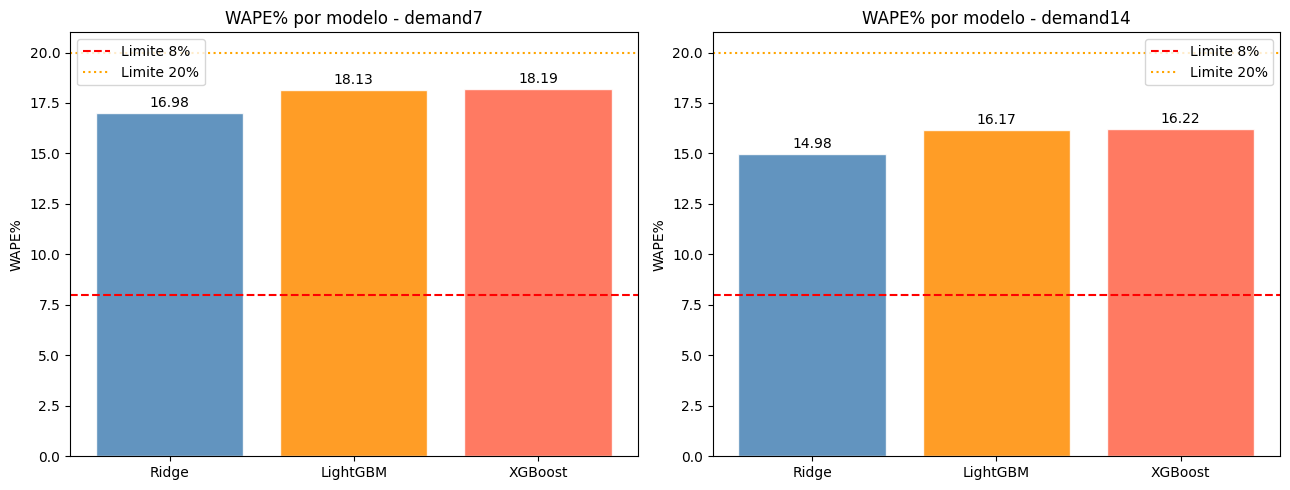

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, target, titulo in [
    (axes[0], 'demand7',  'WAPE% por modelo - demand7'),
    (axes[1], 'demand14', 'WAPE% por modelo - demand14'),
]:
    sub = resultados[resultados['Target']==target]
    ax.bar(sub['Modelo'], sub['WAPE%'],
           color=['steelblue','darkorange','tomato'], edgecolor='white', alpha=0.85)
    ax.axhline(8,  color='red',    ls='--', lw=1.5, label='Limite 8%')
    ax.axhline(20, color='orange', ls=':',  lw=1.5, label='Limite 20%')
    ax.set_title(titulo)
    ax.set_ylabel('WAPE%')
    ax.legend()
    for i, v in enumerate(sub['WAPE%']):
        ax.text(i, v + 0.3, str(v), ha='center')

plt.tight_layout()
plt.show()

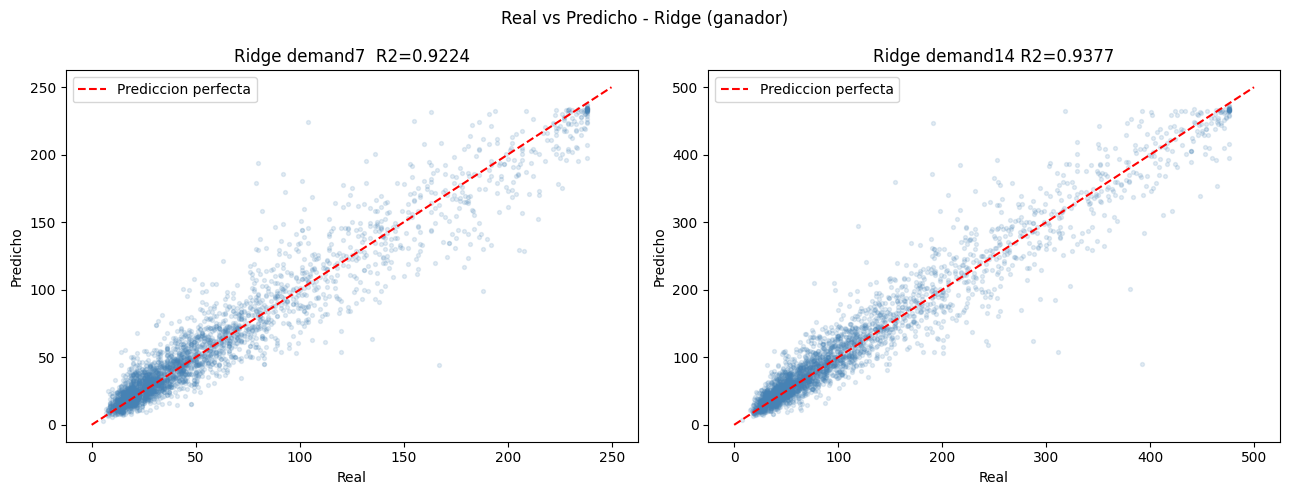

In [38]:
# Real vs predicho - Ridge (ganador)
muestra_idx = np.random.choice(len(y7_test), min(3000, len(y7_test)), replace=False)
real7  = y7_test.values[muestra_idx]
pred7  = pred_ridge7[muestra_idx]
real14 = y14_test.values[muestra_idx]
pred14 = pred_ridge14[muestra_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, r, p, titulo in [
    (axes[0], real7,  pred7,  f'Ridge demand7  R2={r2_score(y7_test, pred_ridge7):.4f}'),
    (axes[1], real14, pred14, f'Ridge demand14 R2={r2_score(y14_test, pred_ridge14):.4f}'),
]:
    ax.scatter(r, p, alpha=0.15, s=8, color='steelblue')
    lim = max(r.max(), p.max()) * 1.05
    ax.plot([0,lim],[0,lim], 'r--', lw=1.5, label='Prediccion perfecta')
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicho')
    ax.set_title(titulo)
    ax.legend()

plt.suptitle('Real vs Predicho - Ridge (ganador)', fontsize=12)
plt.tight_layout()
plt.show()

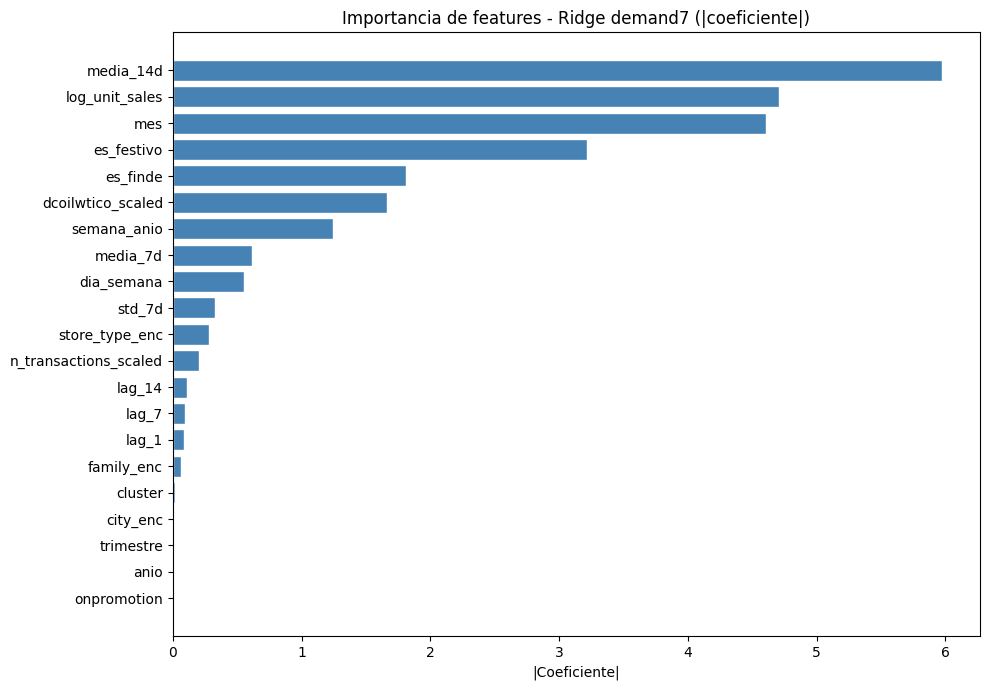

In [39]:
# Importancia de features - Ridge demand7 (coeficientes)
fi = pd.DataFrame({
    'Feature':    FEATURES,
    'Coeficiente': np.abs(ridge7.coef_)
}).sort_values('Coeficiente', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(fi['Feature'], fi['Coeficiente'], color='steelblue', edgecolor='white')
plt.title('Importancia de features - Ridge demand7 (|coeficiente|)')
plt.xlabel('|Coeficiente|')
plt.tight_layout()
plt.show()



---

**Entrenamiento - MODELO PERECE (clasificacion)**

Predice si un producto es perecible (1) o no (0). Se comparan Regresion Logistica, LightGBM y XGBoost.

In [40]:
print('Distribucion de perece en train y test:')
print('  Train - clase 1:', yp_train.mean().round(3), '  clase 0:', (1-yp_train.mean()).round(3))
print('  Test  - clase 1:', yp_test.mean().round(3),  '  clase 0:', (1-yp_test.mean()).round(3))

Distribucion de perece en train y test:
  Train - clase 1: 0.297   clase 0: 0.703
  Test  - clase 1: 0.299   clase 0: 0.701


**Entrenamiento - REGRESION LOGISTICA (referencia)**

In [41]:
lr = LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced')
lr.fit(X_train, yp_train)
pred_lr = lr.predict(X_test)

Precision: 0.711564320487178
              precision    recall  f1-score   support

No perecible       0.82      0.76      0.79    353166
   Perecible       0.51      0.60      0.55    150305

    accuracy                           0.71    503471
   macro avg       0.67      0.68      0.67    503471
weighted avg       0.73      0.71      0.72    503471



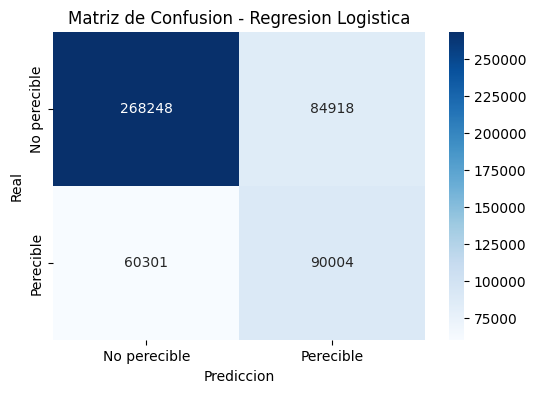

In [42]:
print('Precision:', accuracy_score(yp_test, pred_lr))
print(classification_report(yp_test, pred_lr, target_names=['No perecible','Perecible']))

cm_lr = confusion_matrix(yp_test, pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No perecible','Perecible'],
            yticklabels=['No perecible','Perecible'])
plt.title('Matriz de Confusion - Regresion Logistica')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

**Entrenamiento - LIGHTGBM CLASIFICADOR**

In [43]:
lgbm_cls = lgb.LGBMClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.04,
    num_leaves=63,
    class_weight='balanced',
    random_state=SEED,
    verbose=-1
)
lgbm_cls.fit(X_train, yp_train)
pred_lgbm_cls = lgbm_cls.predict(X_test)

Precision: 1.0
              precision    recall  f1-score   support

No perecible       1.00      1.00      1.00    353166
   Perecible       1.00      1.00      1.00    150305

    accuracy                           1.00    503471
   macro avg       1.00      1.00      1.00    503471
weighted avg       1.00      1.00      1.00    503471



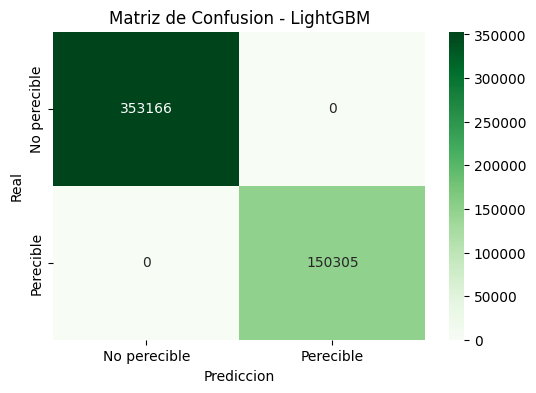

In [44]:
print('Precision:', accuracy_score(yp_test, pred_lgbm_cls))
print(classification_report(yp_test, pred_lgbm_cls, target_names=['No perecible','Perecible']))

cm_lgbm_cls = confusion_matrix(yp_test, pred_lgbm_cls)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lgbm_cls, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No perecible','Perecible'],
            yticklabels=['No perecible','Perecible'])
plt.title('Matriz de Confusion - LightGBM')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

**Entrenamiento - XGBOOST CLASIFICADOR**

In [45]:
n_neg = (yp_train == 0).sum()
n_pos = (yp_train == 1).sum()
scale_pos = n_neg / n_pos  # balance de clases

xgb_cls = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=SEED,
    verbosity=0
)
xgb_cls.fit(X_train, yp_train)
pred_xgb_cls = xgb_cls.predict(X_test)

Precision: 1.0
              precision    recall  f1-score   support

No perecible       1.00      1.00      1.00    353166
   Perecible       1.00      1.00      1.00    150305

    accuracy                           1.00    503471
   macro avg       1.00      1.00      1.00    503471
weighted avg       1.00      1.00      1.00    503471



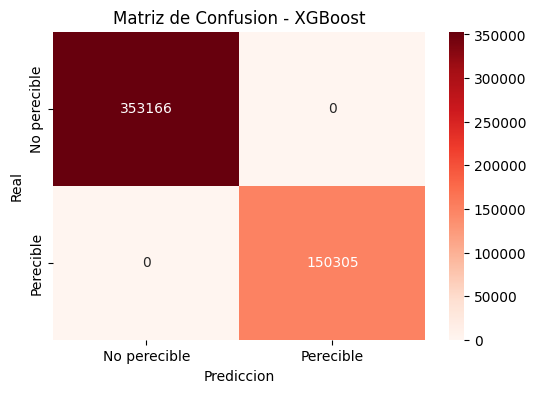

In [46]:
print('Precision:', accuracy_score(yp_test, pred_xgb_cls))
print(classification_report(yp_test, pred_xgb_cls, target_names=['No perecible','Perecible']))

cm_xgb_cls = confusion_matrix(yp_test, pred_xgb_cls)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb_cls, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No perecible','Perecible'],
            yticklabels=['No perecible','Perecible'])
plt.title('Matriz de Confusion - XGBoost')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

**Curva ROC - clasificacion perece**

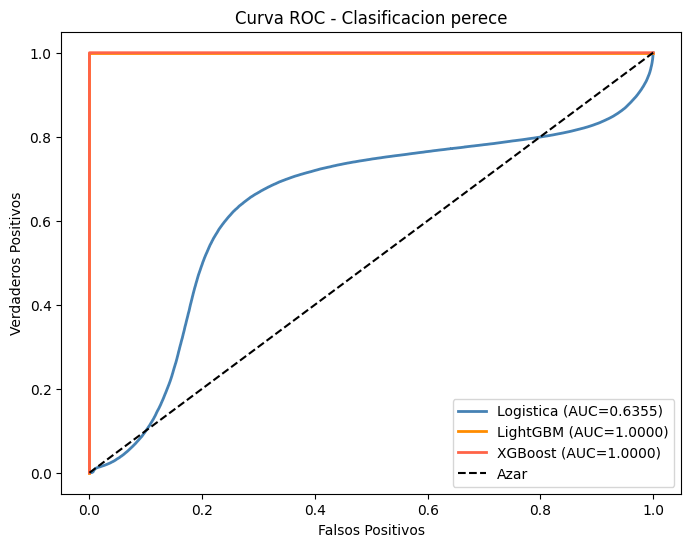

In [47]:
plt.figure(figsize=(8, 6))

for nombre, modelo, color in [
    ('Logistica', lr,       'steelblue'),
    ('LightGBM',  lgbm_cls, 'darkorange'),
    ('XGBoost',   xgb_cls,  'tomato'),
]:
    prob = modelo.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(yp_test, prob)
    auc = roc_auc_score(yp_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={auc:.4f})')

plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Azar')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curva ROC - Clasificacion perece')
plt.legend()
plt.show()

In [48]:
# Tabla comparativa perece
res_cls = pd.DataFrame([
    {'Modelo':'Logistica', 'Accuracy': round(accuracy_score(yp_test,pred_lr),4),
     'AUC': round(roc_auc_score(yp_test, lr.predict_proba(X_test)[:,1]),4)},
    {'Modelo':'LightGBM',  'Accuracy': round(accuracy_score(yp_test,pred_lgbm_cls),4),
     'AUC': round(roc_auc_score(yp_test, lgbm_cls.predict_proba(X_test)[:,1]),4)},
    {'Modelo':'XGBoost',   'Accuracy': round(accuracy_score(yp_test,pred_xgb_cls),4),
     'AUC': round(roc_auc_score(yp_test, xgb_cls.predict_proba(X_test)[:,1]),4)},
])
print(res_cls.to_string(index=False))

   Modelo  Accuracy    AUC
Logistica    0.7116 0.6355
 LightGBM    1.0000 1.0000
  XGBoost    1.0000 1.0000


---

**Guardar modelos**

In [49]:
modelos_ganadores = {
    'ridge_demand7.pkl':  ridge7,
    'ridge_demand14.pkl': ridge14,
    'xgb_perece.pkl':     xgb_cls,
}

for nombre, modelo in modelos_ganadores.items():
    with open(nombre, 'wb') as f:
        pickle.dump(modelo, f)
    tam = os.path.getsize(nombre) / 1024
    print(f'{nombre:<25}  {tam:.0f} KB')


ridge_demand7.pkl          1 KB
ridge_demand14.pkl         1 KB
xgb_perece.pkl             568 KB


In [50]:
# Metadata
meta = {
    'features':     FEATURES,
    'mejor_reg':    'Ridge',
    'mejor_cls':    'XGBoost',
    'corte':        str(corte),
    'resultados_reg': resultados.to_dict(orient='records'),
    'resultados_cls': res_cls.to_dict(orient='records')
}
with open('modelo_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2, default=str)

with open('scalers.pkl', 'wb') as f:
    pickle.dump({'minmax': mm, 'standard': std_sc}, f)

# ZIP
archivos_zip = list(modelos_ganadores.keys()) + ['modelo_metadata.json', 'scalers.pkl']
with zipfile.ZipFile('favorita_modelos.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in archivos_zip:
        zf.write(f)

print('favorita_modelos.zip:', round(os.path.getsize('favorita_modelos.zip')/1024/1024, 2), 'MB')

try:
    from google.colab import files
    files.download('favorita_modelos.zip')
except:
    print('Guardado en:', os.path.abspath('favorita_modelos.zip'))

favorita_modelos.zip: 0.13 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>